# 009 Native Jupyter Widget TDGL Player

This version uses native `ipywidgets` only: a `widgets.Image` receives PNG bytes from the kernel, controls are normal widget buttons/sliders, and playback runs in a daemon thread that updates widget state. It does not start an HTTP server, does not allocate a port, does not use `/proxy`, and does not embed an iframe.

Reference points from the Jupyter docs: widgets display in the notebook output area, widget properties are synchronized state, `widgets.Image` accepts image bytes, and background threads can update widgets without blocking the kernel.


In [19]:
from pathlib import Path
import io
import threading
import time

import h5py
import matplotlib as mpl
import numpy as np
from PIL import Image, ImageDraw
from scipy.interpolate import griddata

# Config
H5_PATH = Path('sim_output.h5')
if not H5_PATH.exists():
    H5_PATH = Path('notebooks/sim_output.h5')

NX, NY = 100, 50
PSI_VMAX = 1.05
FRAME_W, FRAME_H = 760, 470
PANEL_W, PANEL_H = 360, 180
FPS_DEFAULT = 10

with h5py.File(H5_PATH, 'r') as f:
    _points = np.array(f['solution/device/mesh/sites'])
    _edges = np.array(f['solution/device/mesh/edge_mesh/edges'])
    _edge_dirs = np.array(f['solution/device/mesh/edge_mesh/directions'])
    _dual_lengths = np.array(f['solution/device/mesh/edge_mesh/dual_edge_lengths'])
    TOTAL = len(f['data'].keys())

_xmin, _xmax = _points[:, 0].min(), _points[:, 0].max()
_ymin, _ymax = _points[:, 1].min(), _points[:, 1].max()
_gx = np.linspace(_xmin, _xmax, NX)
_gy = np.linspace(_ymin, _ymax, NY)
_GX, _GY = np.meshgrid(_gx, _gy)
_grid_pts = np.column_stack([_GX.ravel(), _GY.ravel()])

s1x, s2x = _points[_edges[:, 0], 0], _points[_edges[:, 1], 0]
_cross = ((s1x <= 0) & (s2x > 0)) | ((s1x > 0) & (s2x <= 0))

cmap_psi = mpl.colormaps['inferno']
cmap_mu = mpl.colormaps['RdBu_r']

# mu range is still a compact scalar. It can be estimated from existing frames once.
_mu_maxes = []
with h5py.File(H5_PATH, 'r') as f:
    for i in range(TOTAL):
        try:
            _mu_maxes.append(float(np.abs(np.array(f[f'data/{i}/mu'])).max()))
        except Exception:
            pass
MU_VMAX = float(np.percentile(_mu_maxes, 99)) if _mu_maxes and max(_mu_maxes) > 0 else 1.0

print(f'Loaded mesh. Existing frames: {TOTAL}, cross-section edges: {_cross.sum()}')
print(f'mu vmax (p99 over existing frames): {MU_VMAX:.4f}')


Loaded mesh. Existing frames: 3376, cross-section edges: 28
mu vmax (p99 over existing frames): 3.6046


In [20]:
def total_frames():
    with h5py.File(H5_PATH, 'r') as f:
        return len(f['data'].keys())


class IVCache:
    """Incremental 1D cache for all existing I-V points.

    Heatmaps are expensive and are not stored globally. I-V is compact, so this
    cache appends every existing point and can keep following a growing H5 file.
    """
    def __init__(self, h5_path, poll_interval=1.0, batch_size=64):
        self.h5_path = h5_path
        self.poll_interval = poll_interval
        self.batch_size = batch_size
        self.lock = threading.RLock()
        self.stop_event = threading.Event()
        self.thread = None
        self.I = []
        self.V = []
        self.t = []
        self.last_total = 0
        self.error = None

    def start(self):
        self.stop()
        self.stop_event.clear()
        self.thread = threading.Thread(target=self._worker, daemon=True)
        self.thread.start()

    def stop(self):
        if self.thread and self.thread.is_alive():
            self.stop_event.set()
            self.thread.join(timeout=1)

    def _frame_iv(self, f, idx):
        d = f[f'data/{idx}']
        J = np.array(d['normal_current']) + np.array(d['supercurrent'])
        I_val = float(np.sum(J[_cross] * _edge_dirs[_cross, 0] * _dual_lengths[_cross]))
        try:
            mu_rs = np.array(d['running_state/mu'])
            dt_rs = np.array(d['running_state/dt'])
            voltage_samples = mu_rs[0] - mu_rs[1]
            dt_sum = float(dt_rs.sum())
            V_val = float(np.sum(voltage_samples * dt_rs) / dt_sum) if dt_sum > 0 else float(voltage_samples.mean())
        except Exception:
            V_val = 0.0
        t_val = float(d.attrs.get('time', idx))
        return I_val, V_val, t_val

    def update_available(self, target=None):
        with self.lock:
            start = len(self.I)
        with h5py.File(self.h5_path, 'r') as f:
            available = len(f['data'].keys())
            end = available if target is None else min(available, int(target) + 1)
            while start < end:
                batch_end = min(end, start + self.batch_size)
                batch = [self._frame_iv(f, i) for i in range(start, batch_end)]
                with self.lock:
                    self.I.extend(x[0] for x in batch)
                    self.V.extend(x[1] for x in batch)
                    self.t.extend(x[2] for x in batch)
                    self.last_total = available
                start = batch_end
        return self.size()

    def ensure(self, idx):
        with self.lock:
            if len(self.I) > idx:
                return len(self.I)
        return self.update_available(target=idx)

    def _worker(self):
        while not self.stop_event.is_set():
            try:
                self.update_available()
                self.error = None
            except Exception as exc:
                self.error = exc
            self.stop_event.wait(self.poll_interval)

    def arrays(self, upto=None):
        with self.lock:
            n = len(self.I) if upto is None else min(len(self.I), int(upto) + 1)
            return np.array(self.I[:n]), np.array(self.V[:n]), np.array(self.t[:n])

    def ranges(self):
        I, V, _ = self.arrays()
        if len(I) == 0:
            return 0.0, 1.0, 0.0, 1.0
        I_min, I_max = float(I.min()), float(I.max())
        V_min, V_max = float(V.min()), float(V.max())
        if I_min == I_max:
            I_min -= 0.5; I_max += 0.5
        if V_min == V_max:
            V_min -= 0.5; V_max += 0.5
        return I_min, I_max, V_min, V_max

    def size(self):
        with self.lock:
            return len(self.I)

    def status(self):
        with self.lock:
            return {
                'cached_points': len(self.I),
                'last_seen_frames': self.last_total,
                'error': repr(self.error) if self.error else None,
            }


try:
    iv_cache.stop()
except NameError:
    pass

iv_cache = IVCache(H5_PATH, poll_interval=1.0, batch_size=128)
iv_cache.ensure(0)
iv_cache.start()
print(f'I-V cache watcher started: {iv_cache.status()}')

def cache_all_existing_iv():
    # Same logic as the watcher: cache every frame that exists right now.
    return iv_cache.update_available()

def stop_iv_cache_watcher():
    iv_cache.stop()
    return iv_cache.status()


def _interpolate(raw):
    return griddata(_points, raw, _grid_pts, method='cubic', fill_value=0.0).reshape(NY, NX)


def _field_rgba(idx, field):
    with h5py.File(H5_PATH, 'r') as f:
        if field == 'psi':
            raw = np.abs(np.array(f[f'data/{idx}/psi']))
        else:
            raw = np.array(f[f'data/{idx}/mu'])
    Z = _interpolate(raw)
    if field == 'psi':
        norm = np.clip(np.clip(Z, 0, None) / PSI_VMAX, 0, 1)
        return (cmap_psi(norm) * 255).astype(np.uint8)
    norm = np.clip((Z + MU_VMAX) / (2 * MU_VMAX), 0, 1)
    return (cmap_mu(norm) * 255).astype(np.uint8)


def _draw_iv(draw, idx, box):
    iv_cache.ensure(idx)
    hist_I, hist_V, hist_t = iv_cache.arrays()
    cur_I, cur_V, cur_t = iv_cache.arrays(upto=idx)
    I_min, I_max, V_min, V_max = iv_cache.ranges()
    I_den = I_max - I_min or 1.0
    V_den = V_max - V_min or 1.0

    x0, y0, x1, y1 = box
    left, right, top, bottom = x0 + 54, x1 - 20, y0 + 18, y1 - 34
    draw.rectangle([x0, y0, x1, y1], fill=(30, 30, 30))
    for t in range(5):
        y = top + (1 - t / 4) * (bottom - top)
        draw.line([(left, y), (right, y)], fill=(50, 50, 50))
        draw.text((left - 48, y - 6), f'{V_min + t / 4 * V_den:.2f}', fill=(150, 150, 150))
    for t in range(5):
        x = left + t / 4 * (right - left)
        draw.text((x - 18, bottom + 8), f'{I_min + t / 4 * I_den:.2f}', fill=(150, 150, 150))
    draw.line([(left, top), (left, bottom), (right, bottom)], fill=(105, 105, 105), width=1)

    pts = []
    for I, V in zip(hist_I, hist_V):
        x = left + (float(I) - I_min) / I_den * (right - left)
        y = top + (1 - (float(V) - V_min) / V_den) * (bottom - top)
        pts.append((x, y))
    if len(pts) > 1:
        draw.line(pts, fill=(233, 69, 96), width=2)
    if len(cur_I):
        x = left + (float(cur_I[-1]) - I_min) / I_den * (right - left)
        y = top + (1 - (float(cur_V[-1]) - V_min) / V_den) * (bottom - top)
        draw.ellipse([x - 6, y - 6, x + 6, y + 6], fill=(0, 0, 0))
        draw.ellipse([x - 3, y - 3, x + 3, y + 3], fill=(255, 255, 255))

    draw.text(((left + right) // 2 - 82, y1 - 18), 'I (transport current)', fill=(150, 150, 150))
    draw.text((8, y0 + 70), 'V', fill=(150, 150, 150))
    if len(cur_t):
        draw.text((right - 190, top + 4), f't={cur_t[-1]:.3g}, IV cached={iv_cache.size()}', fill=(150, 150, 150))


_render_lock = threading.RLock()

def _render_frame_png_uncached(idx):
    idx = int(idx)
    canvas = Image.new('RGBA', (FRAME_W, FRAME_H), (30, 30, 30, 255))
    draw = ImageDraw.Draw(canvas)

    psi = Image.fromarray(_field_rgba(idx, 'psi'), mode='RGBA').resize((PANEL_W, PANEL_H), Image.Resampling.NEAREST)
    mu = Image.fromarray(_field_rgba(idx, 'mu'), mode='RGBA').resize((PANEL_W, PANEL_H), Image.Resampling.NEAREST)
    canvas.paste(psi, (14, 42))
    canvas.paste(mu, (386, 42))

    draw.text((14, 16), f'TDGL frame {idx} / {total_frames() - 1}', fill=(235, 235, 235))
    draw.text((156, 226), '|psi| inferno', fill=(120, 120, 120))
    draw.text((528, 226), 'mu RdBu', fill=(120, 120, 120))
    _draw_iv(draw, idx, (14, 252, 746, 454))

    buf = io.BytesIO()
    canvas.convert('RGB').save(buf, format='PNG', optimize=False)
    return buf.getvalue()


def render_frame_png(idx):
    # Heatmaps are intentionally not globally cached. Realtime playback owns a small
    # buffer and evicts old frames; I-V history stays as compact 1D arrays.
    with _render_lock:
        return _render_frame_png_uncached(int(idx))

render_frame_png(0)
print('Renderer ready. I-V cache continuously follows all currently existing frames; heatmaps are only cached by the display buffer.')


I-V cache watcher started: {'cached_points': 1, 'last_seen_frames': 3376, 'error': None}
Renderer ready. I-V cache continuously follows all currently existing frames; heatmaps are only cached by the display buffer.



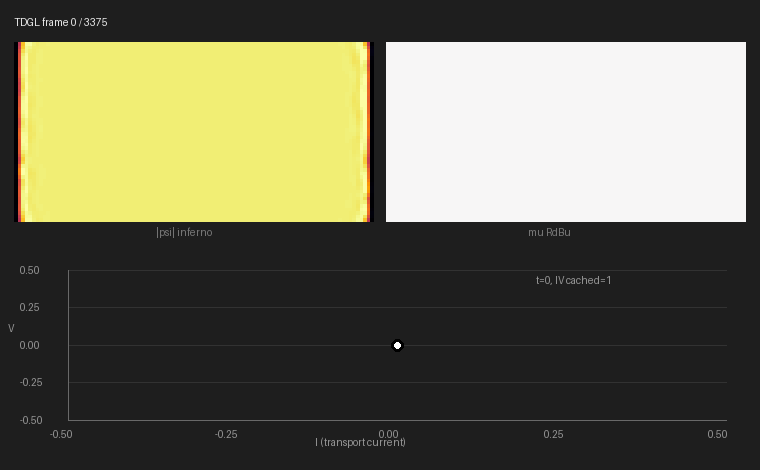

In [21]:
# Sanity check: this should show a static frame even if ipywidgets is not rendering.
import base64
from IPython.display import HTML, display


def png_html(png_bytes, width=FRAME_W):
    b64 = base64.b64encode(png_bytes).decode('ascii')
    return HTML(f'<img src="data:image/png;base64,{b64}" width="{width}" style="display:block;max-width:100%;background:#1e1e1e"/>')


display(png_html(render_frame_png(0)))


In [22]:
# Widget comm diagnostic. If this button does not update the label, ipywidgets
# click/slider events are not reaching the kernel in this frontend session.
import ipywidgets as widgets
from IPython.display import display

_diag_count = 0
_diag_label = widgets.Label(value='click count: 0')
_diag_button = widgets.Button(description='Test click', icon='check')

def _diag_clicked(_):
    global _diag_count
    _diag_count += 1
    _diag_label.value = f'click count: {_diag_count}'

_diag_button.on_click(_diag_clicked)
display(widgets.HBox([_diag_button, _diag_label]))


In [23]:
# Realtime buffered native player.
# This is the closest in-notebook equivalent of 007's request/render loop:
# - render only the current frame on demand
# - keep a small LRU buffer around the playback position
# - replace one displayed Image instead of accumulating output frames
# - no server, no port, no iframe, no /files, no /proxy
import collections
import ipywidgets as widgets
from IPython.display import display

BUFFER_KEEP = 5
LOOK_BEHIND = 2

class RealtimeFrameBuffer:
    def __init__(self, keep=BUFFER_KEEP):
        self.keep = keep
        self.frames = collections.OrderedDict()
        self.lock = threading.RLock()

    def get(self, idx):
        idx = int(idx)
        with self.lock:
            png = self.frames.get(idx)
            if png is not None:
                self.frames.move_to_end(idx)
                return png
        png = render_frame_png(idx)
        with self.lock:
            self.frames[idx] = png
            self.frames.move_to_end(idx)
            self.prune_locked()
        return png

    def prune_locked(self):
        while len(self.frames) > self.keep:
            self.frames.popitem(last=False)

    def keep_near(self, center):
        center = int(center)
        lo = max(0, center - 2)
        hi = min(TOTAL - 1, center)
        with self.lock:
            for key in list(self.frames):
                if key < lo or key > hi:
                    del self.frames[key]


    def clear(self):
        with self.lock:
            self.frames.clear()

    def keys(self):
        with self.lock:
            return list(self.frames.keys())


class RealtimeTDGLWidgetPlayer:
    def __init__(self):
        self.buffer = RealtimeFrameBuffer()
        self.current = 0
        self.playing = False
        self.stop_event = threading.Event()
        self.thread = None
        self.render_lock = threading.RLock()

        self.image = widgets.Image(value=self.buffer.get(0), format='png', width=FRAME_W)
        self.play_button = widgets.Button(description='Play', icon='play', layout=widgets.Layout(width='92px'))
        self.stop_button = widgets.Button(description='Stop', icon='stop', layout=widgets.Layout(width='92px'))
        self.slider = widgets.IntSlider(value=0, min=0, max=total_frames() - 1, step=1, description='Frame', continuous_update=False, layout=widgets.Layout(width='520px'))
        self.fps = widgets.IntSlider(value=6, min=1, max=20, step=1, description='FPS', continuous_update=False, layout=widgets.Layout(width='220px'))
        self.label = widgets.Label(value=f'0 / {total_frames() - 1}')
        self.status = widgets.Label(value='heatmap buffer [0]')

        self.play_button.on_click(self.toggle)
        self.stop_button.on_click(self.stop)
        self.slider.observe(self.on_slider, names='value')

        self.ui = widgets.VBox([
            widgets.HBox([self.play_button, self.stop_button, self.slider, self.label]),
            widgets.HBox([self.fps, self.status]),
            self.image,
        ])

    def display(self):
        display(self.ui)

    def update_status(self):
        keys = self.buffer.keys()
        if keys:
            self.status.value = (f'heatmap buffer {keys} ({len(keys)} frames); I-V cached {iv_cache.size()}/{total_frames()}' if len(keys) <= 8 else f'heatmap buffer {min(keys)}..{max(keys)} ({len(keys)} frames); I-V cached {iv_cache.size()}/{total_frames()}')
        else:
            self.status.value = f'heatmap buffer empty; I-V cached {iv_cache.size()}/{total_frames()}'

    def show(self, idx):
        self.slider.max = total_frames() - 1
        idx = int(max(0, min(self.slider.max, idx)))
        with self.render_lock:
            self.current = idx
            png = self.buffer.get(idx)
            self.image.value = png
            if self.slider.value != idx:
                self.slider.value = idx
            self.label.value = f'{idx} / {self.slider.max}'
            self.buffer.keep_near(idx)
            self.update_status()

    def on_slider(self, change):
        if int(change['new']) != self.current:
            self.show(change['new'])

    def toggle(self, _=None):
        if self.playing:
            self.pause()
        else:
            self.play()

    def play(self):
        if self.thread and self.thread.is_alive():
            return
        self.stop_event.clear()
        self.playing = True
        self.play_button.description = 'Pause'
        self.play_button.icon = 'pause'
        self.thread = threading.Thread(target=self.loop, daemon=True)
        self.thread.start()

    def pause(self):
        self.playing = False
        self.stop_event.set()
        self.play_button.description = 'Play'
        self.play_button.icon = 'play'

    def stop(self, _=None):
        self.pause()
        self.show(0)




    def loop(self):
        while not self.stop_event.is_set():
            next_idx = self.current + 1
            if next_idx >= total_frames():
                self.pause()
                return
            t0 = time.perf_counter()
            self.show(next_idx)
            elapsed = time.perf_counter() - t0
            self.stop_event.wait(max(0.0, 1.0 / max(1, self.fps.value) - elapsed))

try:
    realtime_player.pause()
except NameError:
    pass

realtime_player = RealtimeTDGLWidgetPlayer()
realtime_player.display()


In [18]:
# Optional diagnostics / cleanup.
print('render_frame_png has no global heatmap cache')
# tdgl_player.pause()
# None


render_frame_png has no global heatmap cache
